# Basic Gene Expression Data Analysis

This notebook demonstrates a basic exploratory analysis of gene expression data using Python, as part of my self-taught training in biological data analysis.

## Toy example: simple expression matrix
This section uses a small toy dataset to illustrate basic data manipulation and visualization.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

df = pd.read_csv("../data/gene_expression.csv")
df

,Gene,Sample1,Sample2,Sample3
0,GeneA,5,3,6
1,GeneB,2,8,7
2,GeneC,9,4,5


In [2]:
df.describe()

,Sample1,Sample2,Sample3
count,3.000000,3.000000,3.0
mean,5.333333,5.000000,6.0
std,3.511885,2.645751,1.0
min,2.000000,3.000000,5.0
25%,3.500000,3.500000,5.5
50%,5.000000,4.000000,6.0
75%,7.000000,6.000000,6.5
max,9.000000,8.000000,7.0


In [3]:
df["GeneMeanAcrossSamples"] = df[["Sample1", "Sample2", "Sample3"]].mean(axis=1)

df[["Gene", "GeneMeanAcrossSamples"]].sort_values("GeneMeanAcrossSamples", ascending=False)

,Gene,GeneMeanAcrossSamples
2,GeneC,6.000000
1,GeneB,5.666667
0,GeneA,4.666667


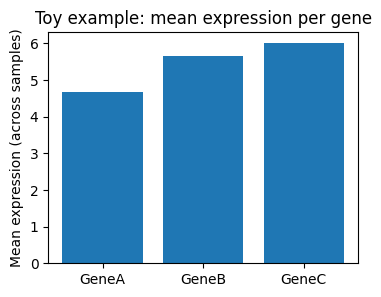

In [4]:
plt.figure(figsize=(4,3))
plt.bar(df["Gene"], df["GeneMeanAcrossSamples"])
plt.ylabel("Mean expression (across samples)")
plt.title("Toy example: mean expression per gene")
plt.show()

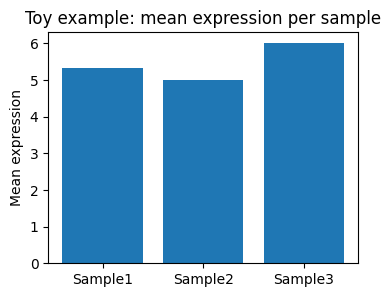

In [5]:
sample_means = df[["Sample1", "Sample2", "Sample3"]].mean()

plt.figure(figsize=(4,3))
plt.bar(sample_means.index, sample_means.values)
plt.ylabel("Mean expression")
plt.title("Toy example: mean expression per sample")
plt.show()

In [6]:
f_stat, p_value = stats.f_oneway(df["Sample1"], df["Sample2"], df["Sample3"])
f_stat, p_value

(0.11475409836065573, 0.8934956990814987)

Although Sample3 showed a slightly higher mean expression level, a one-way ANOVA did not detect a statistically significant difference among the three samples (F = 0.115, p = 0.893), suggesting comparable overall expression levels across samples.

## RNA-seq–like data simulation and analysis
The following analysis uses simulated RNA-seq count data to explore expression distributions and gene-level variability.

In [7]:
import numpy as np
import pandas as pd

rng = np.random.default_rng(42)

n_genes = 10000
n_rep = 3 
groups = ["A"] * n_rep + ["B"] * n_rep
samples = [f"A{i+1}" for i in range(n_rep)] + [f"B{i+1}" for i in range(n_rep)]

lib_sizes = rng.lognormal(mean=0.0, sigma=0.25, size=len(samples))
lib_sizes = lib_sizes / lib_sizes.mean()  

base_mu = rng.lognormal(mean=1.2, sigma=1.0, size=n_genes)

disp = rng.lognormal(mean=-1.2, sigma=0.6, size=n_genes) 
size_param = 1.0 / disp 

de_frac = 0.10
n_de = int(n_genes * de_frac)
de_idx = rng.choice(n_genes, size=n_de, replace=False)

log2fc = rng.normal(loc=0.0, scale=1.0, size=n_de)   
fold_change = 2 ** log2fc

mu = np.zeros((n_genes, len(samples)), dtype=float)
for j, s in enumerate(samples):
    mu[:, j] = base_mu * lib_sizes[j]

b_cols = [i for i, g in enumerate(groups) if g == "B"]
mu[de_idx[:, None], b_cols] *= fold_change[:, None]

counts = np.zeros_like(mu, dtype=int)
for j in range(len(samples)):
    n = size_param
    p = n / (n + mu[:, j])
    counts[:, j] = rng.negative_binomial(n=n, p=p)

genes = [f"Gene{i+1:05d}" for i in range(n_genes)]
df_counts = pd.DataFrame(counts, columns=samples)
df_counts.insert(0, "Gene", genes)

df_counts.head(), df_counts.shape

(        Gene  A1  A2  A3  B1  B2  B3
 0  Gene00001   2   0   2   1   2   7
 1  Gene00002   0   1   1   4   4   1
 2  Gene00003   2   1   5   5   4   7
 3  Gene00004   2   0   2   3   0   0
 4  Gene00005   7   5  13   5   6   0,
 (10000, 7))

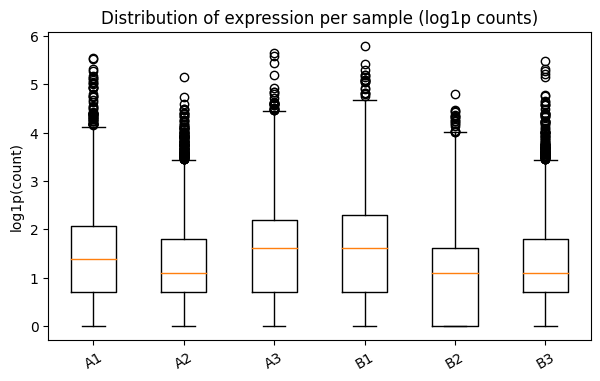

In [8]:
import matplotlib.pyplot as plt

mat = df_counts.set_index("Gene")
log_mat = np.log1p(mat)

plt.figure(figsize=(7,4))
plt.boxplot([log_mat[c].values for c in log_mat.columns], labels=log_mat.columns)
plt.ylabel("log1p(count)")
plt.title("Distribution of expression per sample (log1p counts)")
plt.xticks(rotation=30)
plt.show()

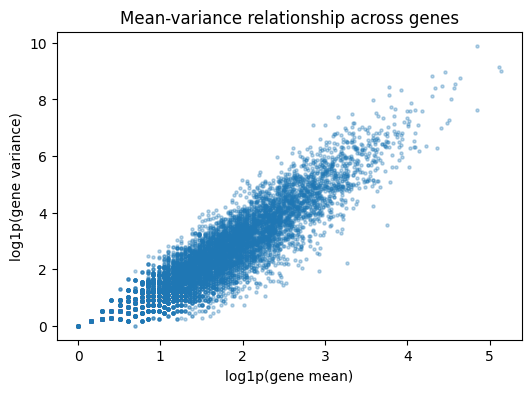

In [9]:
gene_means = mat.mean(axis=1)
gene_vars = mat.var(axis=1)

plt.figure(figsize=(6,4))
plt.scatter(np.log1p(gene_means), np.log1p(gene_vars), s=5, alpha=0.3)
plt.xlabel("log1p(gene mean)")
plt.ylabel("log1p(gene variance)")
plt.title("Mean-variance relationship across genes")
plt.show()

In [10]:
top_n = 20
top_genes = gene_vars.sort_values(ascending=False).head(top_n).index
top_log = log_mat.loc[top_genes]

top_log.head()

,A1,A2,A3,B1,B2,B3
Gene,,,,,,
Gene07133,5.170484,0.000000,2.890372,5.799093,0.693147,5.476464
Gene04136,5.525453,4.465908,5.594711,5.303305,2.995732,5.159055
Gene08086,5.541264,4.189655,5.641907,5.075174,4.290459,5.220356
Gene03136,5.318120,2.397895,3.583519,4.025352,2.944439,5.273000
Gene09259,3.258097,3.931826,4.624973,5.424950,1.791759,3.367296


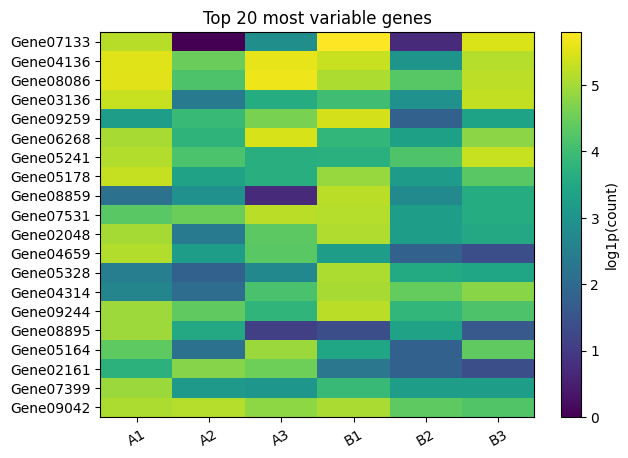

In [11]:
plt.figure(figsize=(7,5))
plt.imshow(top_log.values, aspect="auto")
plt.yticks(range(top_n), top_genes)
plt.xticks(range(len(samples)), samples, rotation=30)
plt.colorbar(label="log1p(count)")
plt.title(f"Top {top_n} most variable genes")
plt.show()